<a href="https://colab.research.google.com/github/lalin15rv-bit/Inteligencia-Artificial/blob/main/RNN/Bitcoin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd           #importamos la libreria

_df = pd.read_csv("/content/Bitcoin_16_9_2025-17_11_2025_historical_data_coinmarketcap.csv", delimiter=';')         #Ayuda a leer nuestro archivo en CSV.
# Ordenamos correctamente
_df = _df.sort_index(ascending=False)       #Los valores serán al menor
_df.head()          #Nos imprime una visualizacion de la lista

,timeOpen,timeClose,timeHigh,timeLow,name,open,high,low,close,volume,marketCap,circulatingSupply,timestamp
397,2024-10-15T00:00:00.000Z,2024-10-15T23:59:59.999Z,2024-10-15T14:02:00.000Z,2024-10-15T15:09:00.000Z,2781,66050.368727,67881.679587,64809.196947,67041.107165,4.886387e+10,1.325307e+12,19768178,2024-10-15T23:59:59.999Z
396,2024-10-16T00:00:00.000Z,2024-10-16T23:59:59.999Z,2024-10-16T11:48:00.000Z,2024-10-16T01:12:00.000Z,2781,67042.461822,68375.292949,66758.725509,67612.720778,3.819519e+10,1.336697e+12,19768628,2024-10-16T23:59:59.999Z
395,2024-10-17T00:00:00.000Z,2024-10-17T23:59:59.999Z,2024-10-17T00:38:00.000Z,2024-10-17T13:37:00.000Z,2781,67617.079571,67912.207640,66647.391211,67399.833492,3.279090e+10,1.332817e+12,19769128,2024-10-17T23:59:59.999Z
394,2024-10-18T00:00:00.000Z,2024-10-18T23:59:59.999Z,2024-10-18T18:47:00.000Z,2024-10-18T00:57:00.000Z,2781,67419.108725,68969.746924,67177.818199,68418.789049,3.685717e+10,1.352611e+12,19769537,2024-10-18T23:59:59.999Z
393,2024-10-19T00:00:00.000Z,2024-10-19T23:59:59.999Z,2024-10-19T03:18:00.000Z,2024-10-19T17:03:00.000Z,2781,68418.976662,68668.005810,68024.638235,68362.733110,1.444350e+10,1.351535e+12,19770059,2024-10-19T23:59:59.999Z


In [ ]:
import pandas as pd

_df = pd.read_csv("https://gist.githubusercontent.com/mevangelista-alvarado/6f4f28c00f9e683108637cb3c8d5db89/raw/1ce753283fce23eeab952fa1d660a7069bbe9104/Bitcoin_1_1_2024-6_9_2024_historical_data_coinmarketcap.csv", delimiter=';')      #Hacemos que lea nuestro CSV para nuestro programa
# Ordenamos correctamente
_df = _df.sort_index(ascending=False)       #Los valores serán al menor
_df.head()      #Muestra algunos datos de nuestra base

,timeOpen,timeClose,timeHigh,timeLow,name,open,high,low,close,volume,marketCap,timestamp
158,2024-01-03T00:00:00.000Z,2024-01-03T23:59:59.999Z,2024-01-03T09:40:00.000Z,2024-01-03T12:10:00.000Z,2781,44961.603187,45503.241795,40813.534868,42848.175641,4.634232e+10,8.393459e+11,2024-01-03T23:59:59.999Z
157,2024-01-04T00:00:00.000Z,2024-01-04T23:59:59.999Z,2024-01-04T22:22:00.000Z,2024-01-04T01:26:00.000Z,2781,42855.814761,44770.023414,42675.174007,44179.921701,3.044809e+10,8.654825e+11,2024-01-04T23:59:59.999Z
156,2024-01-05T00:00:00.000Z,2024-01-05T23:59:59.999Z,2024-01-05T23:07:00.000Z,2024-01-05T01:49:00.000Z,2781,44192.978699,44353.285859,42784.718266,44162.691630,3.233603e+10,8.651827e+11,2024-01-05T23:59:59.999Z
155,2024-01-06T00:00:00.000Z,2024-01-06T23:59:59.999Z,2024-01-06T00:10:00.000Z,2024-01-06T07:07:00.000Z,2781,44178.954607,44227.631307,43475.156431,43989.194093,1.609250e+10,8.618220e+11,2024-01-06T23:59:59.999Z
154,2024-01-07T00:00:00.000Z,2024-01-07T23:59:59.999Z,2024-01-07T14:09:00.000Z,2024-01-07T23:45:00.000Z,2781,43998.464243,44495.571471,43662.228627,43943.097229,1.933057e+10,8.609518e+11,2024-01-07T23:59:59.999Z


In [ ]:
'timeOpen', 'timeClose', 'timeHigh', 'timeLow', 'name', 'open', 'high',
'low', 'close', 'volume', 'marketCap', 'timestamp'        #Nombre de las columnas

('low', 'close', 'volume', 'marketCap', 'timestamp')

In [ ]:
df = _df[['timeOpen', 'open', 'high', 'low', 'close']]      #elegimos las columnas para un nuevo datarame

In [ ]:
dates = df[['close']].values        #Extrae los valores de las columnas

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))       #Hacemos que los datos se trasormen de un ranfgo de 0 y 1
scaled_data = scaler.fit_transform(dates)           #Se guarda en una varible nuestros datos

In [ ]:
window_size = 60          #indicamos el tamaño de la ventana

In [ ]:
import numpy as np

def create_sequences(data, window_size):      #Toma los datos y el tamaño de la ventana
    sequences = []      #almacenan los valores
    labels = []
    for i in range(len(data) - window_size):        #comienza el bucle
        sequences.append(data[i:i+window_size])
        # El precio es la primera columna
        labels.append(data[i + window_size, 0])       #Se toma el valor que sigue inmediatamente a esa secuencia
    return np.array(sequences), np.array(labels)      #Despues de terminar el bucle y se hacen los arreglos

X, y = create_sequences(scaled_data, window_size)

In [ ]:
split = int(len(X) * 0.8)     #multiplica el resultado por 0.8
X_train, y_train = X[:split], y[:split]     #Tienen las primeras secuencias y las primeras etiquetas
X_test, y_test = X[split:], y[split:]

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, SimpleRNN

model = Sequential()        #Se añaden las capas una detras de otra
model.add(SimpleRNN(units=120, return_sequences=True, input_shape=(window_size, X_train.shape[2])))       #120 neuronas, se apilan las cpas, [2] es el número de características por paso de tiempo
model.add(SimpleRNN(units=60, return_sequences=False))        #60 neuronas, solo devuelve el ultimo paso de tiempo
model.add(Dense(units=30))      #30 neuronas
model.add(Dense(units=1))     #Es la capa de salida

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
from tensorflow.keras.optimizers import Adam        #Importamos adam para que sea mas facil el proceso

learning_rate = 0.001         #Definimos la tasa de aprendizaje
adam_optimizer = Adam(learning_rate=learning_rate)

# Compilar el modelo
model.compile(optimizer=adam_optimizer, loss='mean_squared_error')      #aqui el modelo copila los datos

# Entrenar el modelo
model.fit(X_train, y_train, batch_size=1, epochs=10)    #Colocamos el numero de epocas por las que queremos utilizar nuestros datos

Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.1052
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0242
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0595
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0146
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0120
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0134
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0122
Epoch 8/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0051
Epoch 9/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0089
Epoch 10/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0128


In [ ]:
# Hacer predicciones
predictions = model.predict(X_test)     #hacemos la prediccion del modelo

# Desescalar los datos predichos
predictions = scaler.inverse_transform(np.concatenate((predictions, np.zeros((predictions.shape[0], 3))), axis=1))[:,0]
y_test = scaler.inverse_transform(np.concatenate((y_test.reshape(-1, 1), np.zeros((y_test.shape[0], 3))), axis=1))[:,0]     #Con el mismo número de columnas con las que fue originalmente 'entrenado'.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 906ms/step


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print(f"MAE: {mae}")
print(f"RMSE: {rmse}")

MAE: 1931.8909989204233
RMSE: 2239.1868837601346


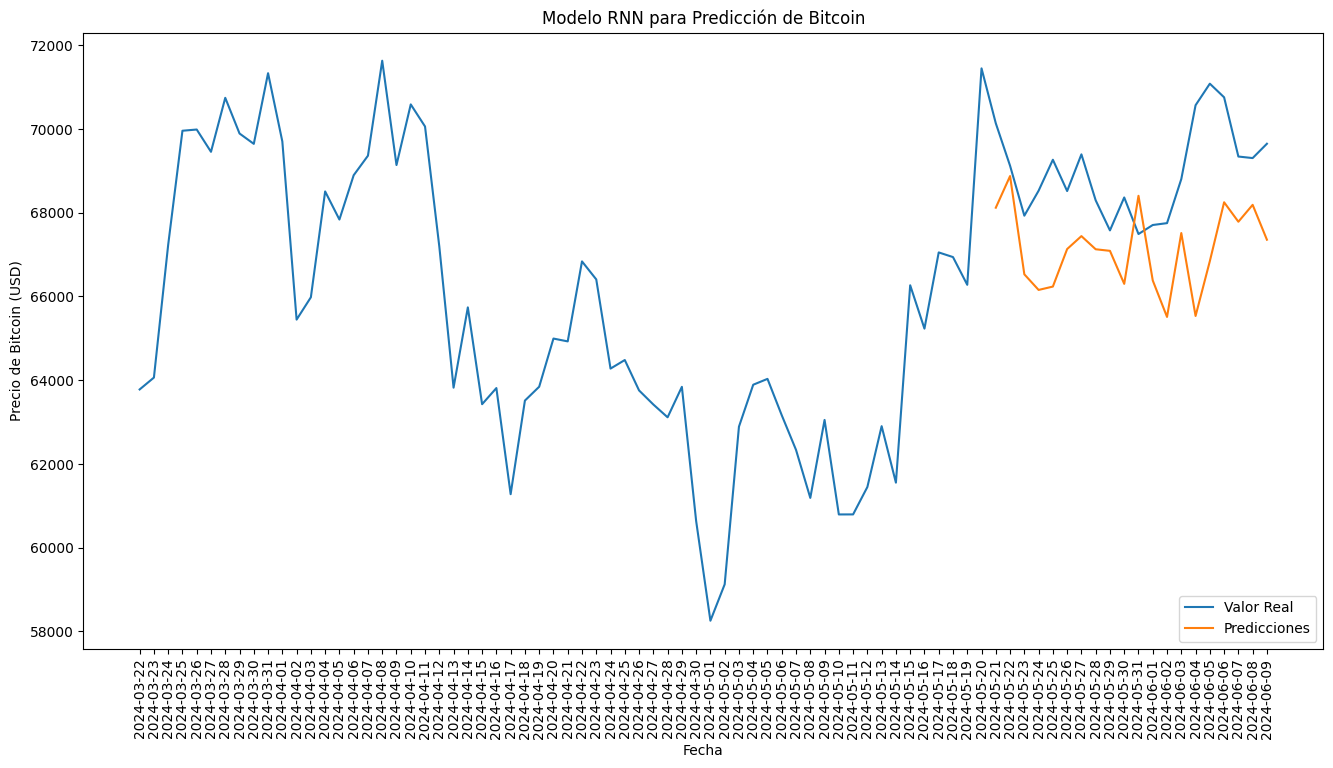

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

valid = df[split:]
# Reiniciar el índice del DataFrame de validación
valid = valid.reset_index(drop=True)
# Inicializar la columna de predicciones con NaN
valid['Predictions'] = np.nan

# Añadir las predicciones al DataFrame de validación desde el punto donde inician las predicciones
valid.loc[window_size:, 'Predictions'] = predictions
dates_valid = pd.to_datetime(valid['timeOpen']).apply(lambda x: x.strftime('%Y-%m-%d')).tolist()

plt.figure(figsize=(16,8))
plt.title('Modelo RNN para Predicción de Bitcoin')
plt.xlabel('Fecha')
plt.ylabel('Precio de Bitcoin (USD)')
plt.plot(dates_valid, valid[['close', 'Predictions']])
plt.legend(['Valor Real', 'Predicciones'], loc='lower right')
plt.xticks(rotation=90)
plt.show()

In [ ]:
# Generar secuencias para los siguientes días
future_sequences = []
# Última secuencia de los valores que tenemos
last_sequence = X[-1]

days = 10
for _ in range(days):
    # Predecir el siguiente valor
    next_value = model.predict(np.array([last_sequence]))[0, 0]

    # Actualizar la secuencia para la siguiente predicción
    last_sequence = np.concatenate((last_sequence[1:], [[next_value]]), axis=0)

    # Añadir la nueva secuencia a las secuencias futuras
    future_sequences.append(last_sequence)

# Convertir las secuencias futuras a un numpy y reshape para la RNN
future_sequences = np.array(future_sequences)
future_sequences = np.reshape(future_sequences, (future_sequences.shape[0], future_sequences.shape[1], 1))

# Hacer predicciones para los siguientes días
future_predictions = model.predict(future_sequences)

# Desescalar los datos predichos para los siguientes días
future_predictions = scaler.inverse_transform(np.concatenate((future_predictions, np.zeros((future_predictions.shape[0], 3))), axis=1))[:,0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


In [ ]:
# Última fecha en los datos reales
last_date = df['timeOpen'].iloc[-1]
future_dates = pd.date_range(start=last_date, periods=days)[1:]     #Tenemos los datos uturos en los que nos ayudan a predecir
future_dates = future_dates.strftime('%Y-%m-%d').tolist()           #Necesitamos los datos realaes para predecir el siguiente dia

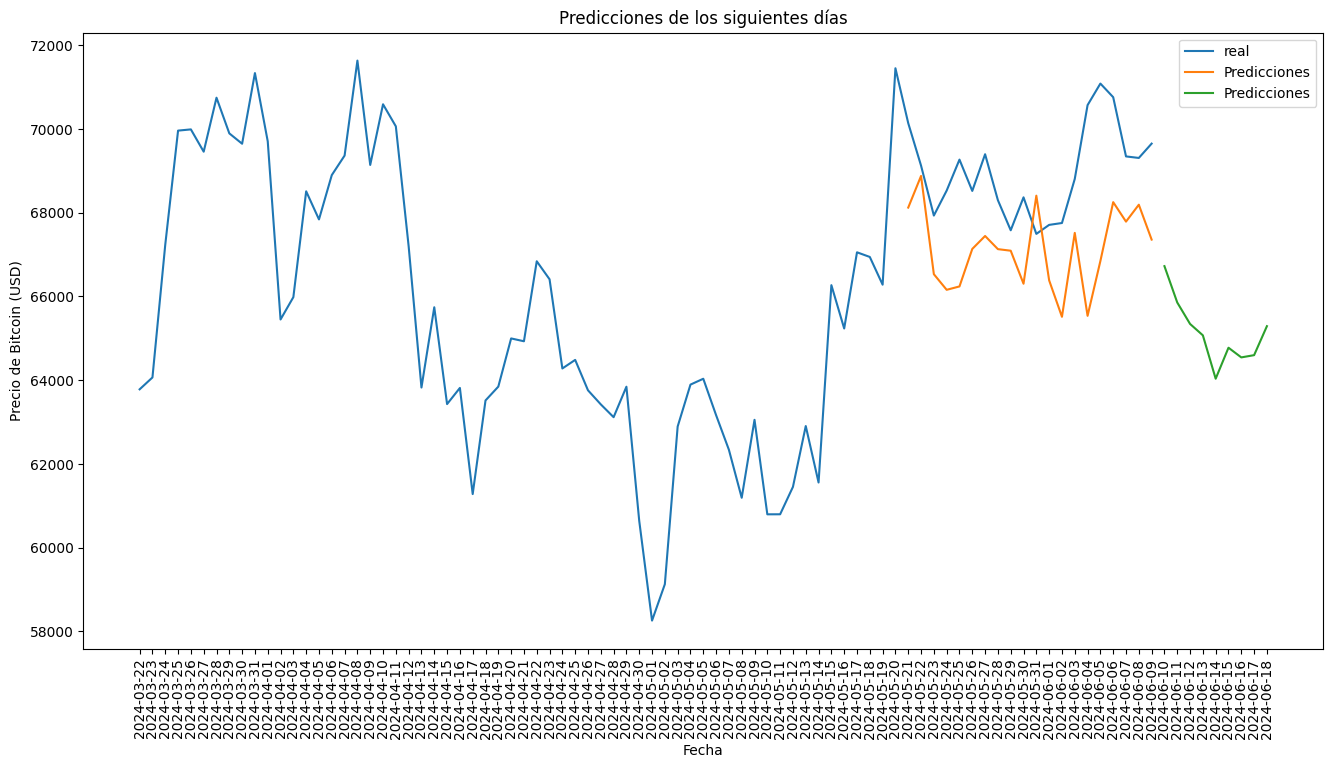

In [ ]:
plt.figure(figsize=(16,8))        #tamaño
plt.title('Predicciones de los siguientes días')      #titulo de la gráfica
plt.xlabel('Fecha')     #nombre del eje X
plt.ylabel('Precio de Bitcoin (USD)')       #nombre del eje Y
plt.plot(dates_valid, valid[['close', 'Predictions']], label=['real', 'Predicciones'])
plt.plot(future_dates, future_predictions[:-1], label='Predicciones')     #indica la prediccion de los datos
plt.legend()
plt.xticks(rotation=90)     #rotacion del texto
plt.show()